<>:63: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x7/ww3bm0kx1mq7v6r3dk8mccw80000gn/T/ipykernel_72945/3791090446.py:63: SyntaxWarning: invalid escape sequence '\c'
  '''ax.text(0.85, 0.95, r'$\chi^2$ = {:.2f}'.format(chi_sq), transform=ax.transAxes, fontsize=16,
/Users/shangguan/Softwares/my_modules/SAGAN/sagan/stellar_continuum.py:294: RuntimeWarning: invalid value encountered in log
  logf_star_A0V = np.interp(logw_even_kpa, logw_star, np.log(flux_A0V))
/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 6000/6000 [01:08<00:00, 87.04it/s]


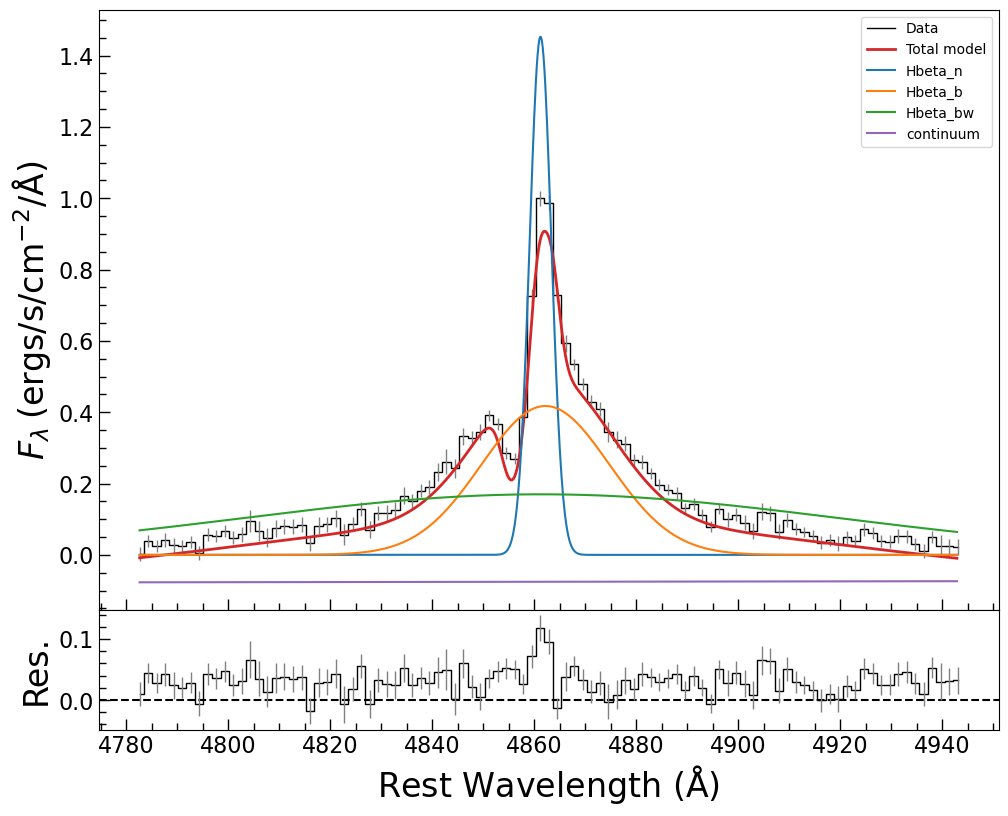

In [1]:
from astropy.io import fits
import numpy as np

import sys
sys.path.append('..')

import galspec  #, galspec_mcmc
from galspec.utils import line_wave_dict, line_label_dict
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting

ls_km = 2.99792e5 # km/s

with fits.open('data/abs_mock_example.fits') as hdul:
    data = hdul[1].data
    
flux=data['flux']
flux_err=data['err']
norm_scale=np.max(flux)
flux=flux/norm_scale
flux_err=flux_err/norm_scale

wave=data['wave']
weight=abs(1/flux_err)

dv_n=0
sigma_n_ha=100
bounds_sigma_n=(100, 425)
fixed_n={'dv': False, 'sigma': False}

ha_n_model=galspec.Line_Gaussian(amplitude=1, wavec=line_wave_dict['Hbeta'],\
                                name='Hbeta_n', dv=dv_n, sigma=sigma_n_ha,\
                                bounds={'sigma': bounds_sigma_n}, fixed= fixed_n)

ha_b_model=galspec.Line_Gaussian(amplitude=0.5, wavec=line_wave_dict['Hbeta'],\
                                name='Hbeta_b', dv=dv_n, sigma=1000,\
                                bounds={'sigma': (425, None),'dv':(-200, 200)}, fixed={})

ha_bw_model=galspec.Line_Gaussian(amplitude=0.2, wavec=line_wave_dict['Hbeta'],\
                                name='Hbeta_bw', dv=dv_n, sigma=1500,\
                                bounds={'sigma': (425, None),'dv':(-200, 200)}, fixed={})

ha_abs_model=galspec.Line_Absorption(tau_0=1, wavec=line_wave_dict['Hbeta'],\
                                    name='Hbeta_abs', dv=-200, sigma=200, Cf=1,\
                                    bounds={'tau_0': (0, None), 'Cf': (0, 1)}, fixed={})

cont_model=models.Polynomial1D(degree=1, c0=0, c1=0, name='continuum')

model_ha=(ha_n_model + ha_b_model + ha_bw_model)*ha_abs_model + cont_model

# LSQ fitting
#fitter=fitting.LevMarLSQFitter()
#model_ha_fit=fitter(model_ha, wave_use_ha, flux_use_ha, weights=weight)

# MCMC fitting
mcmc=galspec.MCMC_Fit(model_ha, wave, flux, flux_err, nwalkers=100)
samples, model_ha_fit, par_names=mcmc.fit()

ax,axr=galspec.plot.plot_fit_new(wave, flux, model_ha_fit, weight=None, error=flux_err)
ax.set_ylabel(r'$F_\lambda\:({\rm ergs/s/cm^{-2}/\AA})$', fontsize=24)
axr.set_xlabel(r'Rest Wavelength ($\mathrm{\AA}$)', fontsize=24)

'''ax.text(0.85, 0.95, r'$\chi^2$ = {:.2f}'.format(chi_sq), transform=ax.transAxes, fontsize=16,
        verticalalignment='top', )
ax.text(0.83, 0.85, r'BIC = {:.2f}'.format(bic), transform=ax.transAxes, fontsize=16,
        verticalalignment='top', )'''

ax.legend(fontsize=10, ncol=1)

#plt.savefig('data/LRD_spec_final_Hab_sample/plots/ha_fitting_abs_2g/'+str(idx)+'.png', dpi=300, bbox_inches='tight')
plt.show()